In [ ]:
# ==============================
# Mount Google Drive
# ==============================
from google.colab import drive
drive.mount('/content/drive')

Found 162916 files belonging to 4 classes.
Using 130333 files for training.
Found 162916 files belonging to 4 classes.
Using 32583 files for validation.
Classes: ['.ipynb_checkpoints', 'color', 'grayscale', 'segmented']
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 criss_cross_attention_1 (Cr  (None, 7, 7, 128)        655873    
 issCrossAttention)                                              
                                                                 
 global_average_pooling2d (G  (None, 128)              0         
 lobalAveragePooling2D)                

2025-08-30 16:13:39.129902: I tensorflow/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8700


   5/4073 [..............................] - ETA: 2:12 - loss: 1.2513 - accuracy: 0.5312 

2025-08-30 16:13:39.406767: I tensorflow/stream_executor/cuda/cuda_blas.cc:1633] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


4073/4073 [==============================] - 73s 17ms/step - loss: 0.0762 - accuracy: 0.9728 - val_loss: 0.0418 - val_accuracy: 0.9815
Epoch 2/5
4073/4073 [==============================] - 70s 17ms/step - loss: 0.0423 - accuracy: 0.9829 - val_loss: 0.0414 - val_accuracy: 0.9823
Epoch 3/5
4073/4073 [==============================] - 70s 17ms/step - loss: 0.0378 - accuracy: 0.9845 - val_loss: 0.0394 - val_accuracy: 0.9831
Epoch 4/5
4073/4073 [==============================] - 71s 18ms/step - loss: 0.0346 - accuracy: 0.9851 - val_loss: 0.0369 - val_accuracy: 0.9835
Epoch 5/5
4073/4073 [==============================] - 70s 17ms/step - loss: 0.0321 - accuracy: 0.9862 - val_loss: 0.0371 - val_accuracy: 0.9840


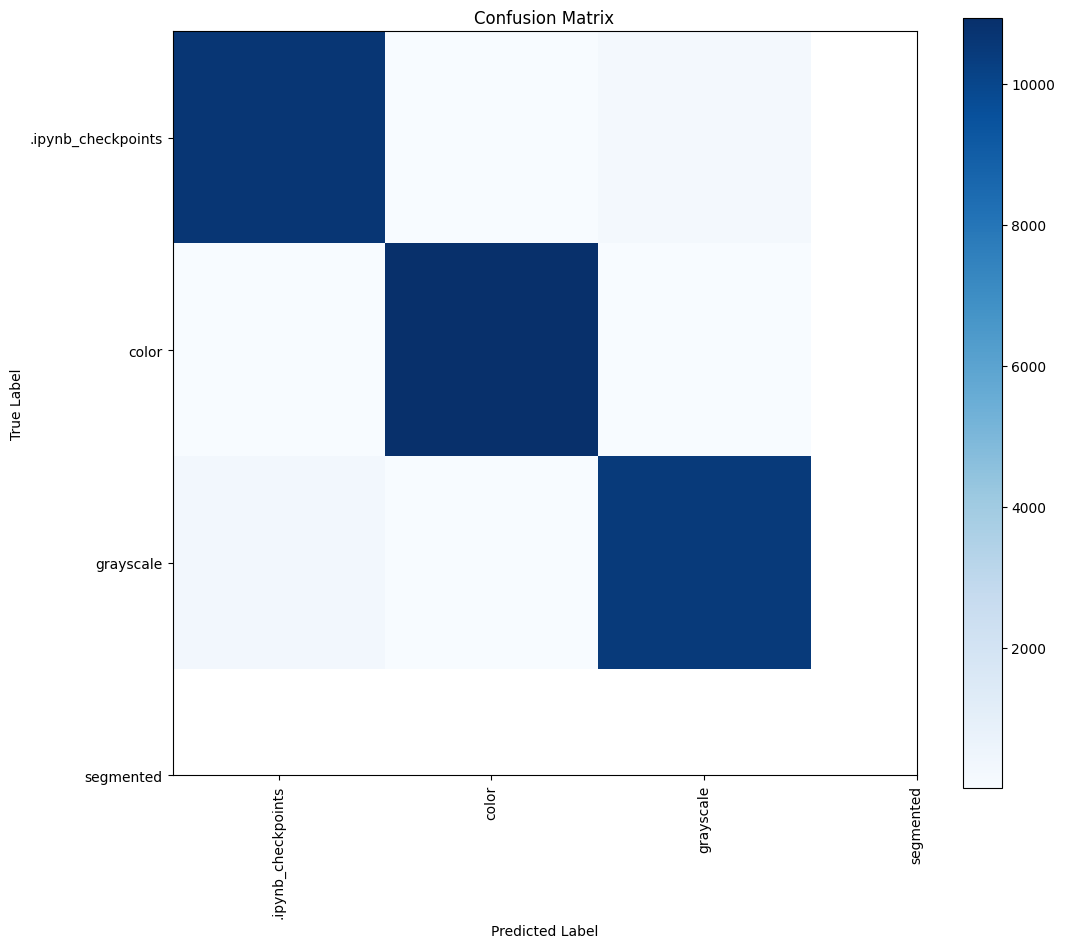


Classification Report:



ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 1. Custom Criss-Cross Attention Layer
# ==============================
class CrissCrossAttention(layers.Layer):
    def __init__(self, filters, **kwargs):
        super(CrissCrossAttention, self).__init__(**kwargs)
        self.filters = filters
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def build(self, input_shape):
        self.query_conv = layers.Conv2D(self.filters, kernel_size=1)
        self.key_conv   = layers.Conv2D(self.filters, kernel_size=1)
        self.value_conv = layers.Conv2D(self.filters, kernel_size=1)
        # ✅ Projection conv to match residual dims
        self.proj_conv  = layers.Conv2D(self.filters, kernel_size=1)
        super().build(input_shape)

    def call(self, x):
        B, H, W, C = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]

        query = self.query_conv(x)
        key   = self.key_conv(x)
        value = self.value_conv(x)

        query_row = tf.reshape(query, [B, H, W, self.filters])
        key_row   = tf.reshape(key,   [B, H, W, self.filters])
        value_row = tf.reshape(value, [B, H, W, self.filters])

        attn_row = tf.matmul(query_row, key_row, transpose_b=True)
        attn_row = tf.nn.softmax(attn_row, axis=-1)
        out_row  = tf.matmul(attn_row, value_row)

        out = tf.reshape(out_row, [B, H, W, self.filters])

        # ✅ Project x to same channel dimension
        x_proj = self.proj_conv(x)

        return self.gamma * out + x_proj


    def compute_output_shape(self, input_shape):
        return input_shape

# ==============================
# 2. Dataset Loading (PlantVillage)
# ==============================
data_dir = "plant_village"  # update if different

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# ✅ Save class names before prefetch
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Optimize dataset
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==============================
# 3. Model with MobileNetV2 + CrissCrossAttention
# ==============================
base_model = MobileNetV2(include_top=False, weights="imagenet", input_shape=img_size + (3,))
base_model.trainable = False  # freeze backbone

inputs = layers.Input(shape=img_size + (3,))
x = base_model(inputs, training=False)

# Add Criss-Cross Attention
x = CrissCrossAttention(filters=128)(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# ==============================
# 4. Train Model
# ==============================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

# ==============================
# 5. Confusion Matrix + Classification Report
# ==============================
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


In [18]:
from sklearn.metrics import classification_report

all_labels = list(range(len(class_names)))

print(classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0))


                    precision    recall  f1-score   support

.ipynb_checkpoints       0.00      0.00      0.00         0
             color       0.97      0.98      0.98     10852
         grayscale       0.99      1.00      1.00     10936
         segmented       0.98      0.97      0.98     10795

         micro avg       0.98      0.98      0.98     32583
         macro avg       0.74      0.74      0.74     32583
      weighted avg       0.98      0.98      0.98     32583



Found 162916 files belonging to 4 classes.
Using 130333 files for training.
Found 162916 files belonging to 4 classes.
Using 32583 files for validation.
Classes: ['.ipynb_checkpoints', 'color', 'grayscale', 'segmented']
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 criss_cross_attention_3 (Cr  (None, 7, 7, 1280)       4919041   
 issCrossAttention)                                              
                                                                 
 global_average_pooling2d_2   (None, 1280)             0         
 (GlobalAveragePooling2D)            

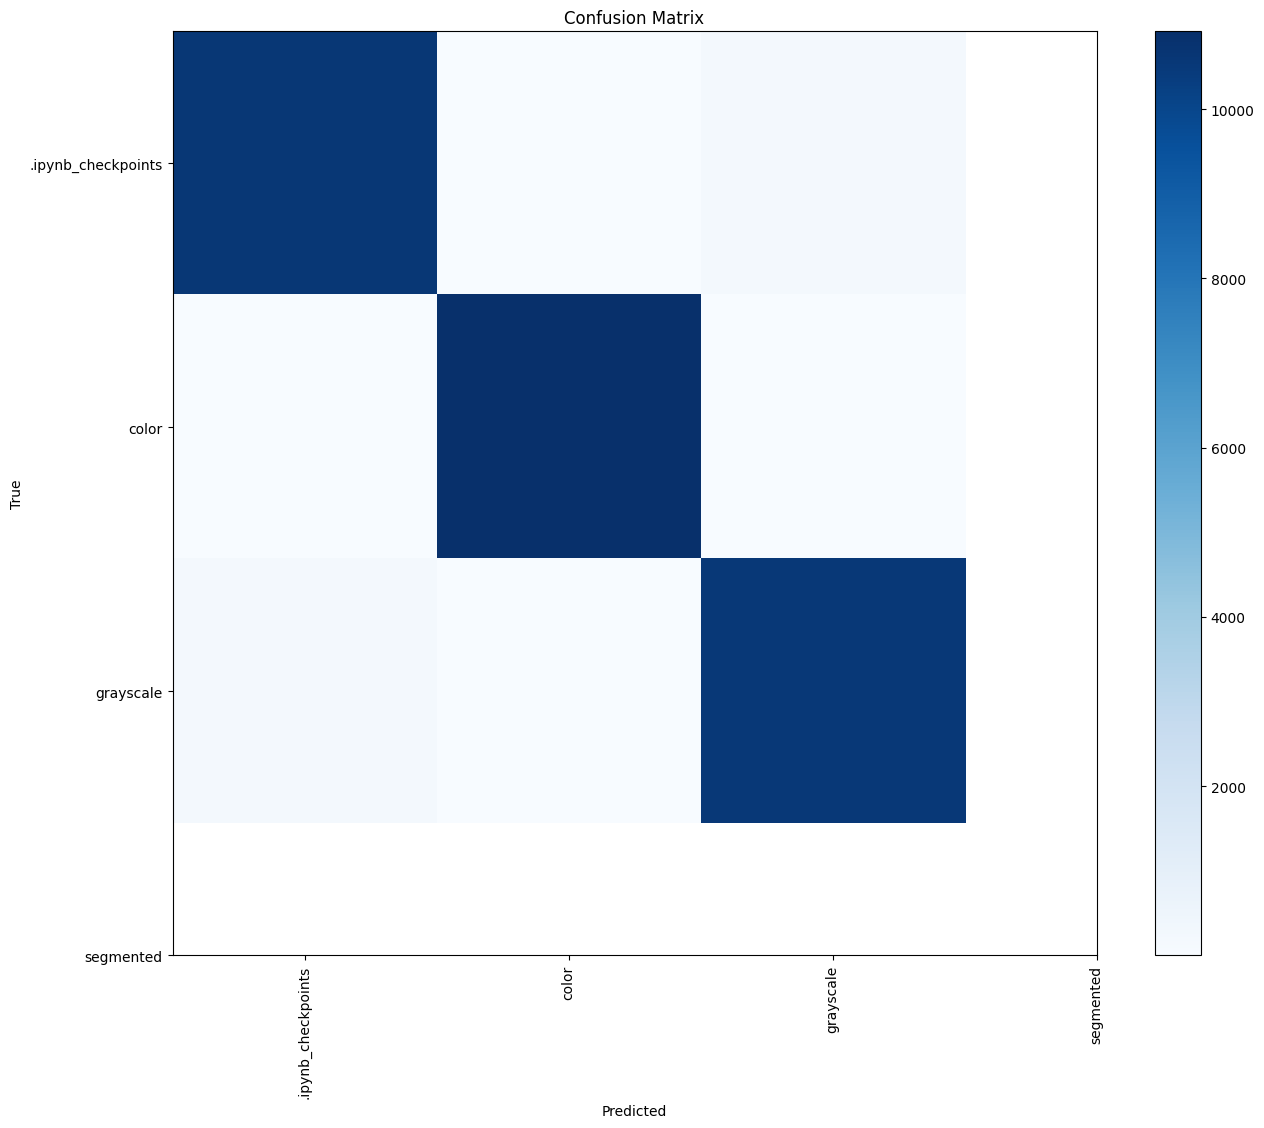


Classification Report:



ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter

In [22]:
# ==============================
# Imports
# ==============================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 1. Custom Criss-Cross Attention Layer
# ==============================
class CrissCrossAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(CrissCrossAttention, self).__init__(**kwargs)
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def build(self, input_shape):
        F = input_shape[-1]  # number of channels
        self.query_conv = layers.Conv2D(F, kernel_size=1)
        self.key_conv   = layers.Conv2D(F, kernel_size=1)
        self.value_conv = layers.Conv2D(F, kernel_size=1)
        super().build(input_shape)

    def call(self, x):
        # Simple channel attention (residual)
        query = self.query_conv(x)
        key   = self.key_conv(x)
        value = self.value_conv(x)
        attn = tf.nn.softmax(tf.matmul(tf.reshape(query, [tf.shape(x)[0], -1, tf.shape(x)[-1]]),
                                       tf.reshape(key, [tf.shape(x)[0], -1, tf.shape(x)[-1]]),
                                       transpose_b=True), axis=-1)
        out = tf.matmul(attn, tf.reshape(value, [tf.shape(x)[0], -1, tf.shape(x)[-1]]))
        out = tf.reshape(out, tf.shape(x))
        return self.gamma * out + x

# ==============================
# 2. Load PlantVillage Dataset
# ==============================
data_dir = "plant_village"  # Update with your path
IMG_SIZE = (224, 224)
BATCH_SIZE = 24

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ✅ Get class names before prefetch
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==============================
# 3. Build Model: MobileNetV2 + CCA
# ==============================
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)

# Add Criss-Cross Attention
x = CrissCrossAttention()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==============================
# 4. Train Model
# ==============================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

# ==============================
# 5. Confusion Matrix + Classification Report
# ==============================
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


In [23]:
from sklearn.metrics import classification_report

all_labels = list(range(len(class_names)))

print(classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0))


                    precision    recall  f1-score   support

.ipynb_checkpoints       0.00      0.00      0.00         0
             color       0.98      0.98      0.98     10852
         grayscale       1.00      1.00      1.00     10936
         segmented       0.98      0.98      0.98     10795

         micro avg       0.98      0.98      0.98     32583
         macro avg       0.74      0.74      0.74     32583
      weighted avg       0.98      0.98      0.98     32583



In [24]:
from sklearn.metrics import classification_report

all_labels = list(range(len(class_names)))

print(
    classification_report(
        y_true, 
        y_pred, 
        labels=all_labels, 
        target_names=class_names, 
        zero_division=0,
        digits=4  # Number of decimal places
    )
)


                    precision    recall  f1-score   support

.ipynb_checkpoints     0.0000    0.0000    0.0000         0
             color     0.9751    0.9776    0.9763     10852
         grayscale     0.9971    0.9984    0.9977     10936
         segmented     0.9797    0.9759    0.9778     10795

         micro avg     0.9840    0.9840    0.9840     32583
         macro avg     0.7380    0.7380    0.7380     32583
      weighted avg     0.9840    0.9840    0.9840     32583



Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Classes detected: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 

1811/1811 [==============================] - 28s 16ms/step - loss: 0.2085 - accuracy: 0.9290 - val_loss: 0.5047 - val_accuracy: 0.8547
Epoch 39/100
1811/1811 [==============================] - 33s 18ms/step - loss: 0.2110 - accuracy: 0.9264 - val_loss: 0.5198 - val_accuracy: 0.8568
Epoch 40/100
1811/1811 [==============================] - 39s 21ms/step - loss: 0.1990 - accuracy: 0.9323 - val_loss: 0.4960 - val_accuracy: 0.8577
Epoch 41/100
1811/1811 [==============================] - 27s 15ms/step - loss: 0.1974 - accuracy: 0.9335 - val_loss: 0.5008 - val_accuracy: 0.8601
Epoch 42/100
1811/1811 [==============================] - 26s 14ms/step - loss: 0.2030 - accuracy: 0.9311 - val_loss: 0.5330 - val_accuracy: 0.8552
Epoch 43/100
1811/1811 [==============================] - 26s 14ms/step - loss: 0.2000 - accuracy: 0.9327 - val_loss: 0.5545 - val_accuracy: 0.8525
Epoch 44/100
1811/1811 [==============================] - 27s 15ms/step - loss: 0.1985 - accuracy: 0.9327 - val_loss: 0.5280 

1811/1811 [==============================] - 27s 15ms/step - loss: 0.1223 - accuracy: 0.9579 - val_loss: 0.6391 - val_accuracy: 0.8534
Epoch 94/100
1811/1811 [==============================] - 26s 14ms/step - loss: 0.1223 - accuracy: 0.9575 - val_loss: 0.6374 - val_accuracy: 0.8524
Epoch 95/100
1811/1811 [==============================] - 25s 14ms/step - loss: 0.1199 - accuracy: 0.9580 - val_loss: 0.6547 - val_accuracy: 0.8499
Epoch 96/100
1811/1811 [==============================] - 27s 15ms/step - loss: 0.1214 - accuracy: 0.9574 - val_loss: 0.6308 - val_accuracy: 0.8544
Epoch 97/100
1811/1811 [==============================] - 26s 14ms/step - loss: 0.1198 - accuracy: 0.9578 - val_loss: 0.6212 - val_accuracy: 0.8524
Epoch 98/100
1811/1811 [==============================] - 27s 15ms/step - loss: 0.1243 - accuracy: 0.9563 - val_loss: 0.6430 - val_accuracy: 0.8512
Epoch 99/100
1811/1811 [==============================] - 27s 15ms/step - loss: 0.1276 - accuracy: 0.9543 - val_loss: 0.6749 

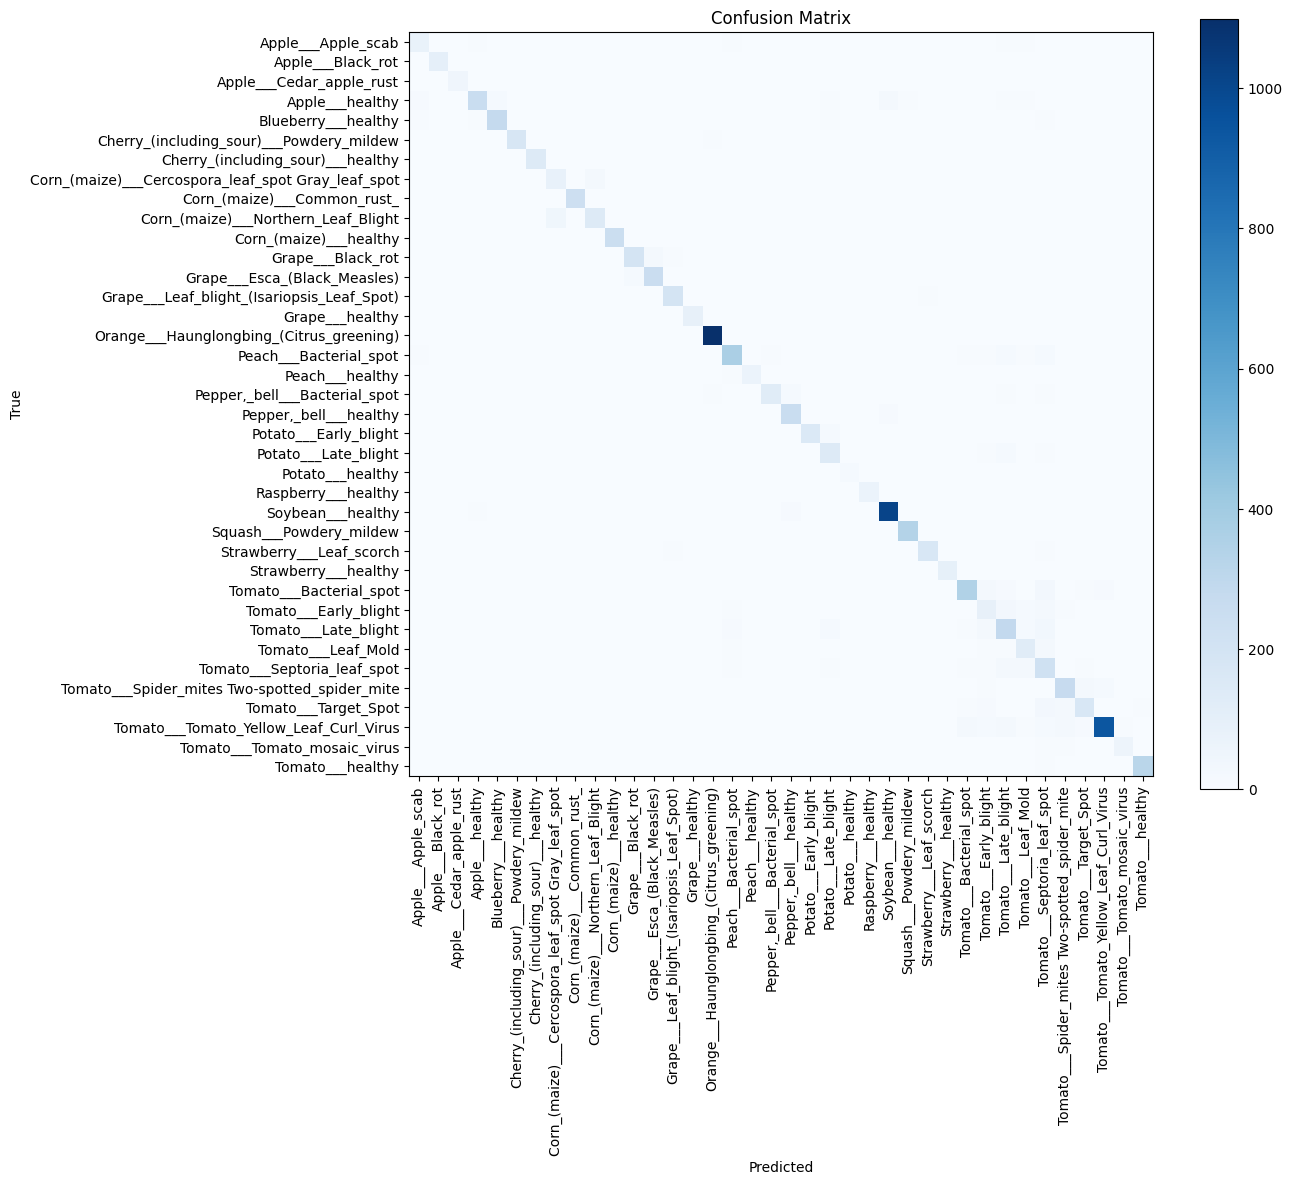


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.6333    0.6333    0.6333       120
                                 Apple___Black_rot     0.9223    0.7661    0.8370       124
                          Apple___Cedar_apple_rust     0.8462    0.7857    0.8148        56
                                   Apple___healthy     0.8528    0.7328    0.7883       348
                               Blueberry___healthy     0.8878    0.8711    0.8794       318
          Cherry_(including_sour)___Powdery_mildew     0.9231    0.8654    0.8933       208
                 Cherry_(including_sour)___healthy     0.9527    0.9592    0.9559       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.6349    0.7339    0.6809       109
                       Corn_(maize)___Common_rust_     0.9833    0.9874    0.9853       238
               Corn_(maize)___Northern_Leaf_Blight    

In [3]:
# ==============================
# Imports
# ==============================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# 1. Remove hidden folders like .ipynb_checkpoints
# ==============================
# data_dir = "plant_village"  # Update with your path
# for folder in os.listdir(data_dir):
#     if folder.startswith("."):
#         path = os.path.join(data_dir, folder)
#         if os.path.isdir(path):
#             os.rename(path, path + "_ignore")  # temporarily rename hidden folders

# ==============================
# 2. Dataset Loading
# ==============================
IMG_SIZE = (224, 224)
BATCH_SIZE = 24

import os
import shutil

data_dir = "plant_village/color"

# Move hidden folders out of the way
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if folder.startswith(".") and os.path.isdir(folder_path):
        shutil.move(folder_path, folder_path + "_backup")  # move to backup folder

# Now load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)



# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==============================
# 3. Custom Criss-Cross Attention Layer
# ==============================
class CrissCrossAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(CrissCrossAttention, self).__init__(**kwargs)
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def build(self, input_shape):
        F = input_shape[-1]  # number of channels
        self.query_conv = layers.Conv2D(F, kernel_size=1)
        self.key_conv   = layers.Conv2D(F, kernel_size=1)
        self.value_conv = layers.Conv2D(F, kernel_size=1)
        super().build(input_shape)

    def call(self, x):
        query = self.query_conv(x)
        key   = self.key_conv(x)
        value = self.value_conv(x)
        attn = tf.nn.softmax(
            tf.matmul(
                tf.reshape(query, [tf.shape(x)[0], -1, tf.shape(x)[-1]]),
                tf.reshape(key, [tf.shape(x)[0], -1, tf.shape(x)[-1]]),
                transpose_b=True
            ), axis=-1
        )
        out = tf.matmul(attn, tf.reshape(value, [tf.shape(x)[0], -1, tf.shape(x)[-1]]))
        out = tf.reshape(out, tf.shape(x))
        return self.gamma * out + x

# ==============================
# 4. Build Model: MobileNetV2 + CCA
# ==============================
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)

x = CrissCrossAttention()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ==============================
# 5. Train Model
# ==============================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100  # adjust epochs
)

# ==============================
# 6. Confusion Matrix + Classification Report
# ==============================
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report with decimal values
all_labels = list(range(num_classes))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0, digits=4))


Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Classes detected: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 

1811/1811 [==============================] - 22s 12ms/step - loss: 0.6897 - accuracy: 0.7918 - val_loss: 0.5787 - val_accuracy: 0.8387
Epoch 40/100
1811/1811 [==============================] - 22s 12ms/step - loss: 0.6863 - accuracy: 0.7939 - val_loss: 0.5762 - val_accuracy: 0.8407
Epoch 41/100
1811/1811 [==============================] - 22s 12ms/step - loss: 0.6827 - accuracy: 0.7935 - val_loss: 0.5730 - val_accuracy: 0.8398
Epoch 42/100
1811/1811 [==============================] - 23s 13ms/step - loss: 0.6817 - accuracy: 0.7941 - val_loss: 0.5717 - val_accuracy: 0.8399
Epoch 43/100
1811/1811 [==============================] - 24s 13ms/step - loss: 0.6787 - accuracy: 0.7930 - val_loss: 0.5677 - val_accuracy: 0.8410
Epoch 44/100
1811/1811 [==============================] - 22s 12ms/step - loss: 0.6736 - accuracy: 0.7954 - val_loss: 0.5665 - val_accuracy: 0.8399
Epoch 45/100
1811/1811 [==============================] - 23s 13ms/step - loss: 0.6731 - accuracy: 0.7961 - val_loss: 0.5632 

1811/1811 [==============================] - 22s 12ms/step - loss: 0.6040 - accuracy: 0.8130 - val_loss: 0.5059 - val_accuracy: 0.8529
Epoch 95/100
1811/1811 [==============================] - 23s 13ms/step - loss: 0.6036 - accuracy: 0.8140 - val_loss: 0.5057 - val_accuracy: 0.8538
Epoch 96/100
1811/1811 [==============================] - 22s 12ms/step - loss: 0.6039 - accuracy: 0.8148 - val_loss: 0.5053 - val_accuracy: 0.8547
Epoch 97/100
1811/1811 [==============================] - 23s 12ms/step - loss: 0.6035 - accuracy: 0.8130 - val_loss: 0.5043 - val_accuracy: 0.8530
Epoch 98/100
1811/1811 [==============================] - 23s 13ms/step - loss: 0.5985 - accuracy: 0.8136 - val_loss: 0.5047 - val_accuracy: 0.8538
Epoch 99/100
1811/1811 [==============================] - 23s 13ms/step - loss: 0.6012 - accuracy: 0.8146 - val_loss: 0.5033 - val_accuracy: 0.8528
Epoch 100/100
1811/1811 [==============================] - 23s 13ms/step - loss: 0.6016 - accuracy: 0.8140 - val_loss: 0.5021

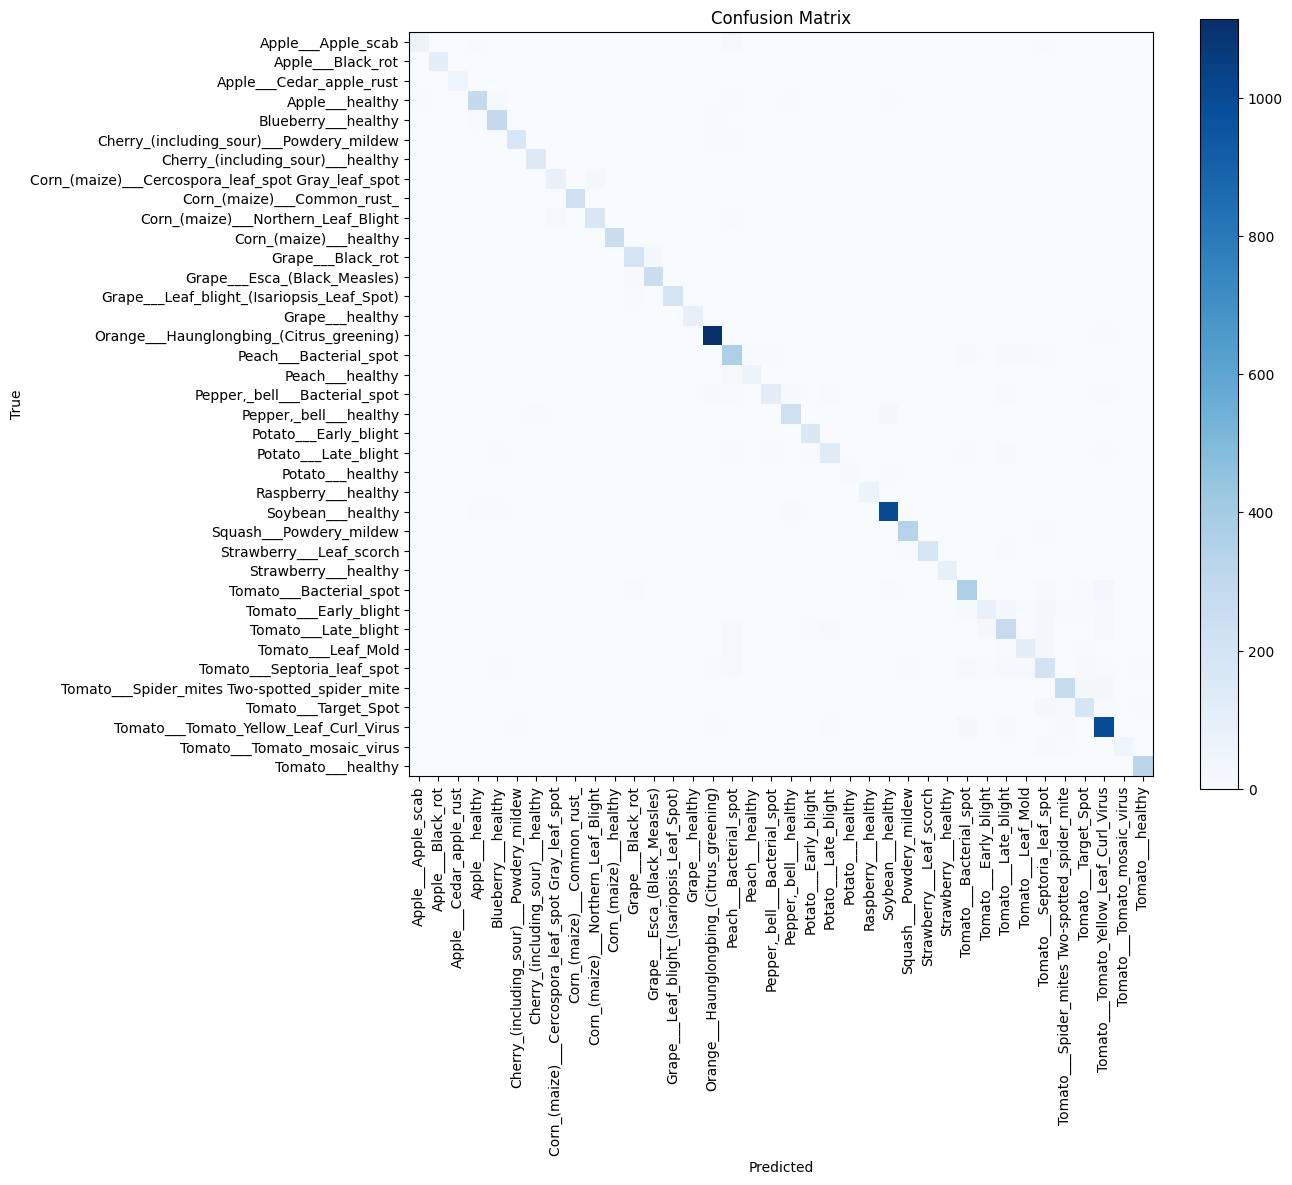


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.7033    0.5333    0.6066       120
                                 Apple___Black_rot     0.8333    0.8468    0.8400       124
                          Apple___Cedar_apple_rust     0.8980    0.7857    0.8381        56
                                   Apple___healthy     0.8567    0.8075    0.8314       348
                               Blueberry___healthy     0.8294    0.8868    0.8571       318
          Cherry_(including_sour)___Powdery_mildew     0.8832    0.8365    0.8593       208
                 Cherry_(including_sour)___healthy     0.9161    0.9660    0.9404       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8316    0.7248    0.7745       109
                       Corn_(maize)___Common_rust_     0.9916    0.9916    0.9916       238
               Corn_(maize)___Northern_Leaf_Blight    

In [4]:
# ==============================
# Imports
# ==============================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# 1. Remove hidden folders like .ipynb_checkpoints
# ==============================
# data_dir = "plant_village"  # Update with your path
# for folder in os.listdir(data_dir):
#     if folder.startswith("."):
#         path = os.path.join(data_dir, folder)
#         if os.path.isdir(path):
#             os.rename(path, path + "_ignore")  # temporarily rename hidden folders

# ==============================
# 2. Dataset Loading
# ==============================
IMG_SIZE = (224, 224)
BATCH_SIZE = 24

import os
import shutil

data_dir = "plant_village/color"

# Move hidden folders out of the way
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if folder.startswith(".") and os.path.isdir(folder_path):
        shutil.move(folder_path, folder_path + "_backup")  # move to backup folder

# Now load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)



# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==============================
# 3. Custom Criss-Cross Attention Layer
# ==============================
class CrissCrossAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(CrissCrossAttention, self).__init__(**kwargs)
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def build(self, input_shape):
        F = input_shape[-1]  # number of channels
        self.query_conv = layers.Conv2D(F, kernel_size=1)
        self.key_conv   = layers.Conv2D(F, kernel_size=1)
        self.value_conv = layers.Conv2D(F, kernel_size=1)
        super().build(input_shape)

    def call(self, x):
        query = self.query_conv(x)
        key   = self.key_conv(x)
        value = self.value_conv(x)
        attn = tf.nn.softmax(
            tf.matmul(
                tf.reshape(query, [tf.shape(x)[0], -1, tf.shape(x)[-1]]),
                tf.reshape(key, [tf.shape(x)[0], -1, tf.shape(x)[-1]]),
                transpose_b=True
            ), axis=-1
        )
        out = tf.matmul(attn, tf.reshape(value, [tf.shape(x)[0], -1, tf.shape(x)[-1]]))
        out = tf.reshape(out, tf.shape(x))
        return self.gamma * out + x

# ==============================
# 4. Build Model: MobileNetV2 + CCA
# ==============================
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)

#x = CrissCrossAttention()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ==============================
# 5. Train Model
# ==============================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100  # adjust epochs
)

# ==============================
# 6. Confusion Matrix + Classification Report
# ==============================
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report with decimal values
all_labels = list(range(num_classes))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0, digits=4))


Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Classes detected: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 

1811/1811 [==============================] - 26s 14ms/step - loss: 0.0269 - accuracy: 0.9921 - val_loss: 0.4868 - val_accuracy: 0.9020
Epoch 37/100
1811/1811 [==============================] - 26s 14ms/step - loss: 0.0272 - accuracy: 0.9910 - val_loss: 0.5365 - val_accuracy: 0.8991
Epoch 38/100
1811/1811 [==============================] - 25s 14ms/step - loss: 0.0264 - accuracy: 0.9914 - val_loss: 0.5897 - val_accuracy: 0.8931
Epoch 39/100
1811/1811 [==============================] - 25s 14ms/step - loss: 0.0239 - accuracy: 0.9923 - val_loss: 0.5132 - val_accuracy: 0.9114
Epoch 40/100
1811/1811 [==============================] - 26s 14ms/step - loss: 0.0315 - accuracy: 0.9903 - val_loss: 0.4894 - val_accuracy: 0.9076
Epoch 41/100
1811/1811 [==============================] - 27s 15ms/step - loss: 0.0231 - accuracy: 0.9933 - val_loss: 0.5299 - val_accuracy: 0.9032
Epoch 42/100
1811/1811 [==============================] - 25s 14ms/step - loss: 0.0220 - accuracy: 0.9934 - val_loss: 0.5713 

1811/1811 [==============================] - 28s 15ms/step - loss: 0.0117 - accuracy: 0.9971 - val_loss: 0.8730 - val_accuracy: 0.8894
Epoch 92/100
1811/1811 [==============================] - 26s 14ms/step - loss: 0.0139 - accuracy: 0.9966 - val_loss: 0.5955 - val_accuracy: 0.9109
Epoch 93/100
1811/1811 [==============================] - 25s 14ms/step - loss: 0.0153 - accuracy: 0.9959 - val_loss: 0.7485 - val_accuracy: 0.8975
Epoch 94/100
1811/1811 [==============================] - 27s 15ms/step - loss: 0.0127 - accuracy: 0.9971 - val_loss: 0.5869 - val_accuracy: 0.9166
Epoch 95/100
1811/1811 [==============================] - 27s 15ms/step - loss: 0.0132 - accuracy: 0.9965 - val_loss: 0.6523 - val_accuracy: 0.9090
Epoch 96/100
1811/1811 [==============================] - 28s 15ms/step - loss: 0.0109 - accuracy: 0.9967 - val_loss: 0.6875 - val_accuracy: 0.9082
Epoch 97/100
1811/1811 [==============================] - 26s 14ms/step - loss: 0.0161 - accuracy: 0.9959 - val_loss: 0.6423 

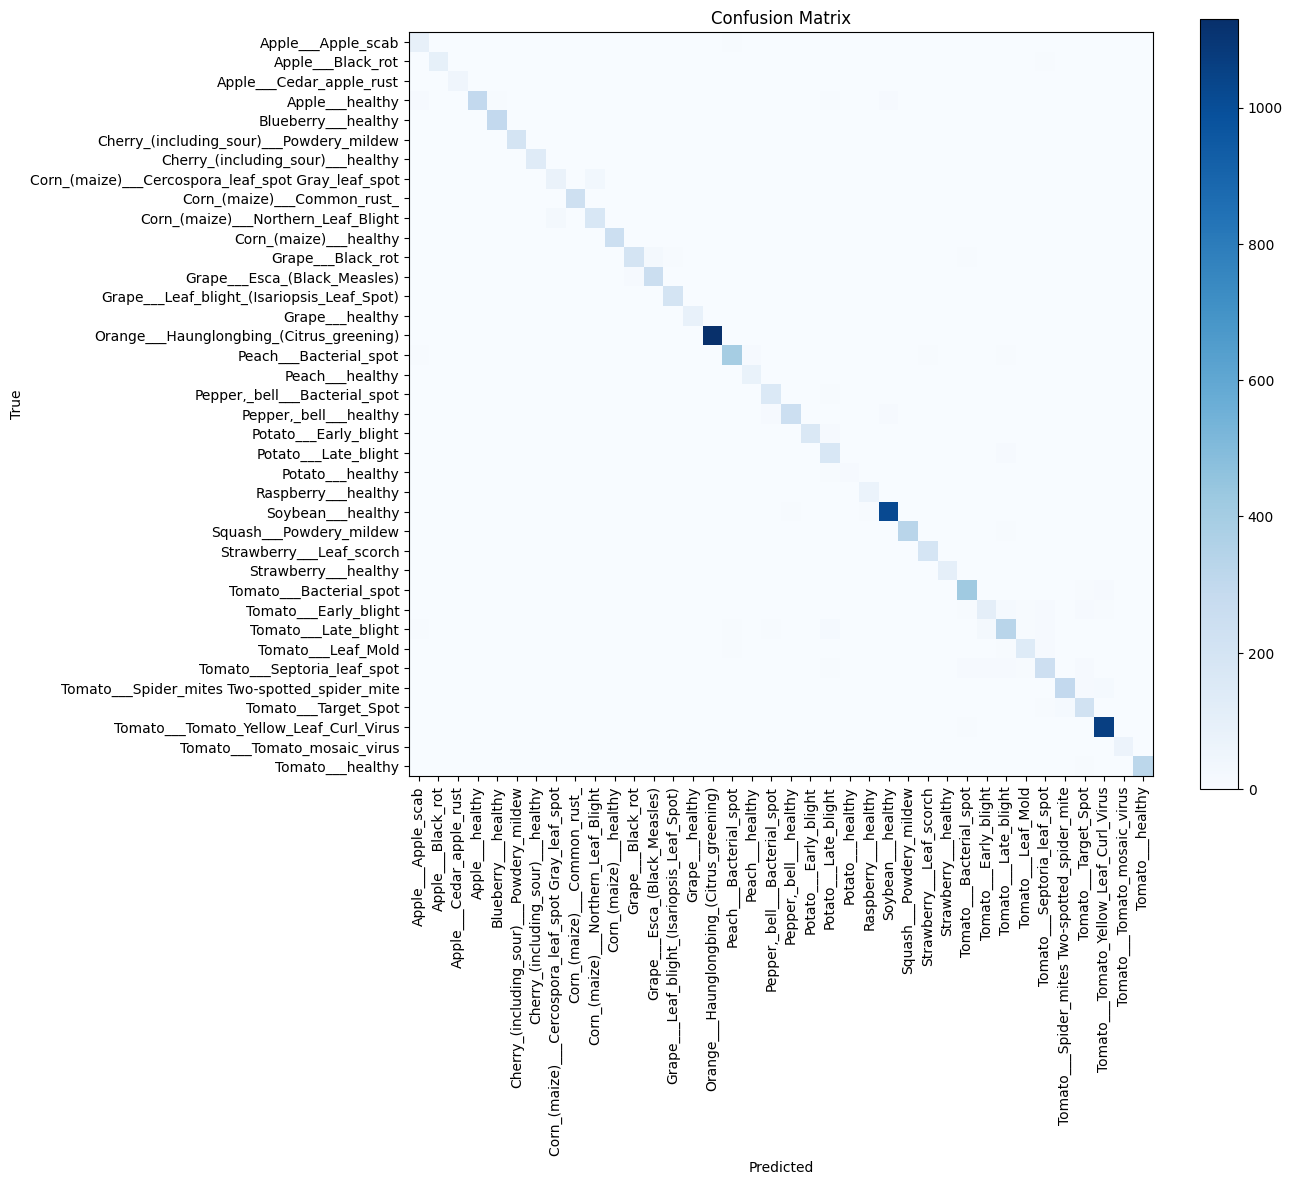


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.6791    0.7583    0.7165       120
                                 Apple___Black_rot     0.9688    0.7500    0.8455       124
                          Apple___Cedar_apple_rust     0.9600    0.8571    0.9057        56
                                   Apple___healthy     0.9130    0.8448    0.8776       348
                               Blueberry___healthy     0.9395    0.9277    0.9335       318
          Cherry_(including_sour)___Powdery_mildew     0.9515    0.9423    0.9469       208
                 Cherry_(including_sour)___healthy     0.9784    0.9252    0.9510       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7826    0.6606    0.7164       109
                       Corn_(maize)___Common_rust_     0.9875    0.9958    0.9916       238
               Corn_(maize)___Northern_Leaf_Blight    

In [5]:
# ==============================
# Imports
# ==============================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# 1. Remove hidden folders like .ipynb_checkpoints
# ==============================
# data_dir = "plant_village"  # Update with your path
# for folder in os.listdir(data_dir):
#     if folder.startswith("."):
#         path = os.path.join(data_dir, folder)
#         if os.path.isdir(path):
#             os.rename(path, path + "_ignore")  # temporarily rename hidden folders

# ==============================
# 2. Dataset Loading
# ==============================
IMG_SIZE = (224, 224)
BATCH_SIZE = 24

import os
import shutil

data_dir = "plant_village/color"

# Move hidden folders out of the way
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if folder.startswith(".") and os.path.isdir(folder_path):
        shutil.move(folder_path, folder_path + "_backup")  # move to backup folder

# Now load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)



# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==============================
# 3. Custom Criss-Cross Attention Layer
# ==============================
class CrissCrossAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(CrissCrossAttention, self).__init__(**kwargs)
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def build(self, input_shape):
        F = input_shape[-1]  # number of channels
        self.query_conv = layers.Conv2D(F, kernel_size=1)
        self.key_conv   = layers.Conv2D(F, kernel_size=1)
        self.value_conv = layers.Conv2D(F, kernel_size=1)
        super().build(input_shape)

    def call(self, x):
        query = self.query_conv(x)
        key   = self.key_conv(x)
        value = self.value_conv(x)
        attn = tf.nn.softmax(
            tf.matmul(
                tf.reshape(query, [tf.shape(x)[0], -1, tf.shape(x)[-1]]),
                tf.reshape(key, [tf.shape(x)[0], -1, tf.shape(x)[-1]]),
                transpose_b=True
            ), axis=-1
        )
        out = tf.matmul(attn, tf.reshape(value, [tf.shape(x)[0], -1, tf.shape(x)[-1]]))
        out = tf.reshape(out, tf.shape(x))
        return self.gamma * out + x

# ==============================
# 4. Build Model: MobileNetV2 + CCA
# ==============================
# ==============================
# 4. Build Model: MobileNetV2 + Extra Conv & Dense layers
# ==============================

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False  # Freeze backbone

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)

# --- Add 2 custom convolutional layers ---
x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)

# Global pooling
x = layers.GlobalAveragePooling2D()(x)

# --- Add 2 custom dense layers ---
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)

# Dropout
x = layers.Dropout(0.4)(x)

# Output layer
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ==============================
# 5. Train Model
# ==============================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100  # adjust epochs
)

# ==============================
# 6. Confusion Matrix + Classification Report
# ==============================
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report with decimal values
all_labels = list(range(num_classes))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0, digits=4))


Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Classes detected: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 

 conv2d_4 (Conv2D)           (None, 7, 7, 256)         2949376   
                                                                 
 conv2d_5 (Conv2D)           (None, 7, 7, 128)         295040    
                                                                 
 global_average_pooling2d_6   (None, 128)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_8 (Dropout)         (None, 128)               0         
                                                                 
 dense_10 (Dense)            (None, 512)               66048     
                                                                 
 dropout_9 (Dropout)         (None, 512)               0         
                                                                 
 dense_11 (Dense)            (None, 256)               131328    
                                                                 
 dropout_1

Epoch 7/40
1811/1811 [==============================] - 32s 18ms/step - loss: 0.1073 - accuracy: 0.9689 - val_loss: 0.4826 - val_accuracy: 0.9008
Epoch 8/40
1811/1811 [==============================] - 32s 18ms/step - loss: 0.0988 - accuracy: 0.9716 - val_loss: 0.4954 - val_accuracy: 0.8856
Epoch 9/40
1811/1811 [==============================] - 32s 18ms/step - loss: 0.0928 - accuracy: 0.9737 - val_loss: 0.5191 - val_accuracy: 0.8926
Epoch 10/40
1811/1811 [==============================] - 33s 18ms/step - loss: 0.0916 - accuracy: 0.9734 - val_loss: 0.4649 - val_accuracy: 0.9068
Epoch 11/40
1811/1811 [==============================] - 32s 18ms/step - loss: 0.0931 - accuracy: 0.9737 - val_loss: 0.4271 - val_accuracy: 0.9083
Epoch 12/40
1811/1811 [==============================] - 32s 18ms/step - loss: 0.0811 - accuracy: 0.9756 - val_loss: 0.5537 - val_accuracy: 0.8949
Epoch 13/40
1811/1811 [==============================] - 33s 18ms/step - loss: 0.0729 - accuracy: 0.9776 - val_loss: 0.50

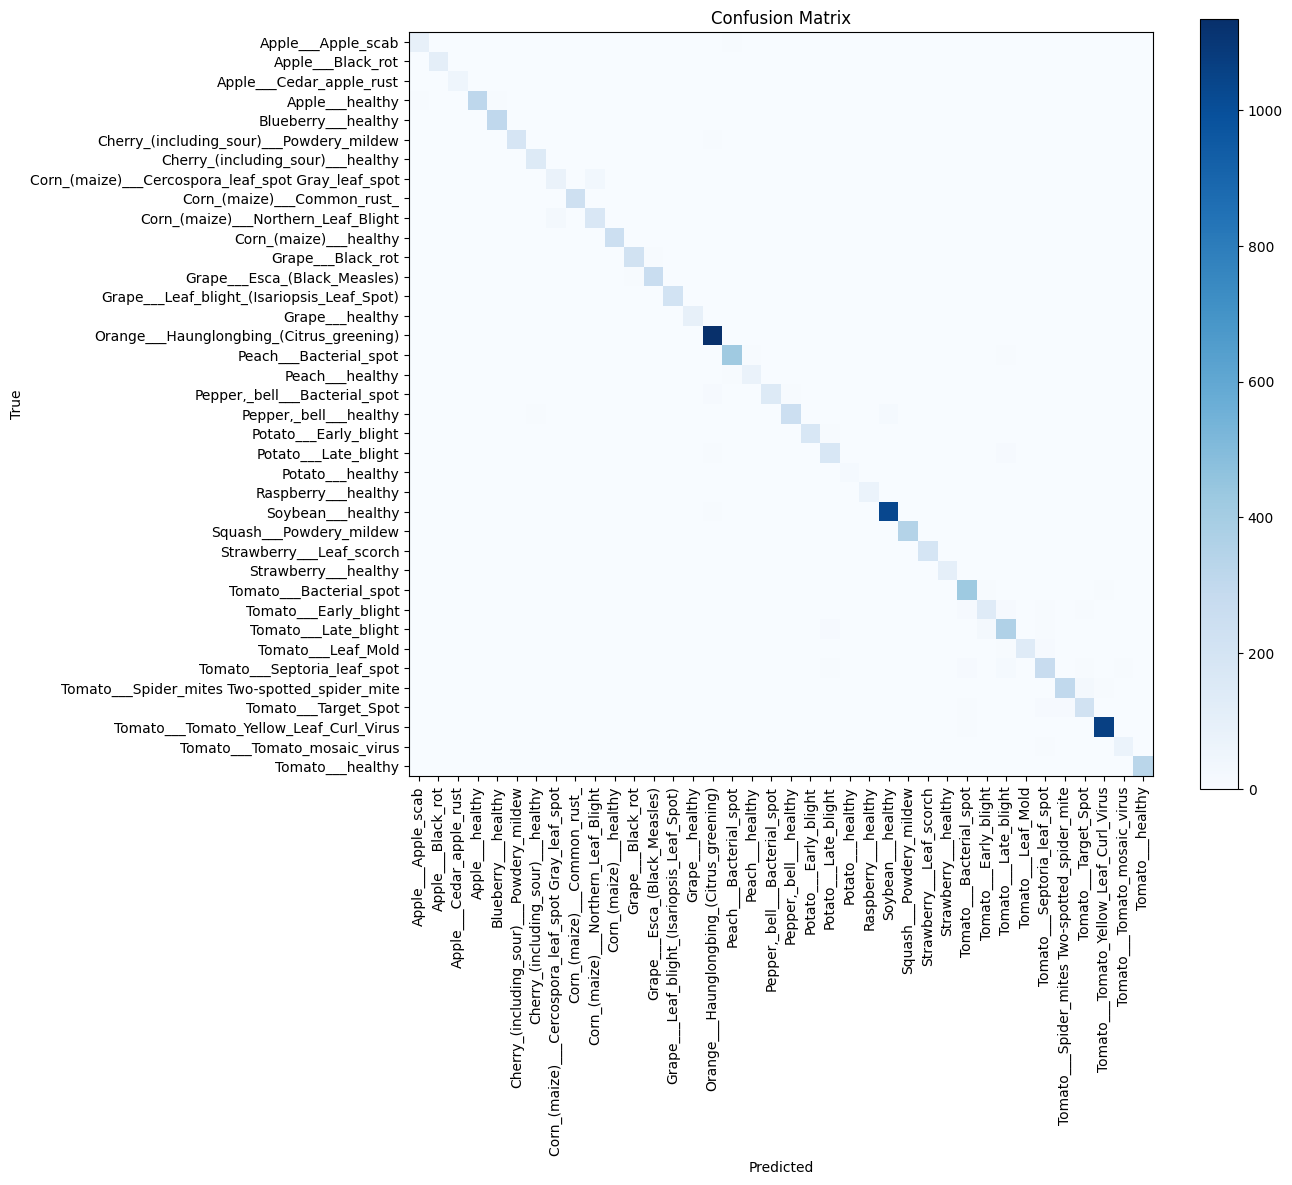


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.7815    0.7750    0.7782       120
                                 Apple___Black_rot     0.9821    0.8871    0.9322       124
                          Apple___Cedar_apple_rust     0.8947    0.9107    0.9027        56
                                   Apple___healthy     0.9263    0.9023    0.9141       348
                               Blueberry___healthy     0.9354    0.9560    0.9456       318
          Cherry_(including_sour)___Powdery_mildew     0.9641    0.9038    0.9330       208
                 Cherry_(including_sour)___healthy     0.9114    0.9796    0.9443       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7849    0.6697    0.7228       109
                       Corn_(maize)___Common_rust_     0.9916    0.9916    0.9916       238
               Corn_(maize)___Northern_Leaf_Blight    

In [6]:
# ==============================
# Imports
# ==============================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# 1. Remove hidden folders like .ipynb_checkpoints
# ==============================
# data_dir = "plant_village"  # Update with your path
# for folder in os.listdir(data_dir):
#     if folder.startswith("."):
#         path = os.path.join(data_dir, folder)
#         if os.path.isdir(path):
#             os.rename(path, path + "_ignore")  # temporarily rename hidden folders

# ==============================
# 2. Dataset Loading
# ==============================
IMG_SIZE = (224, 224)
BATCH_SIZE = 24

import os
import shutil

data_dir = "plant_village/color"

# Move hidden folders out of the way
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if folder.startswith(".") and os.path.isdir(folder_path):
        shutil.move(folder_path, folder_path + "_backup")  # move to backup folder

# Now load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)



# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==============================
# 3. Custom Criss-Cross Attention Layer
# ==============================
class CrissCrossAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(CrissCrossAttention, self).__init__(**kwargs)
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def build(self, input_shape):
        F = input_shape[-1]  # number of channels
        self.query_conv = layers.Conv2D(F, kernel_size=1)
        self.key_conv   = layers.Conv2D(F, kernel_size=1)
        self.value_conv = layers.Conv2D(F, kernel_size=1)
        super().build(input_shape)

    def call(self, x):
        query = self.query_conv(x)
        key   = self.key_conv(x)
        value = self.value_conv(x)
        attn = tf.nn.softmax(
            tf.matmul(
                tf.reshape(query, [tf.shape(x)[0], -1, tf.shape(x)[-1]]),
                tf.reshape(key, [tf.shape(x)[0], -1, tf.shape(x)[-1]]),
                transpose_b=True
            ), axis=-1
        )
        out = tf.matmul(attn, tf.reshape(value, [tf.shape(x)[0], -1, tf.shape(x)[-1]]))
        out = tf.reshape(out, tf.shape(x))
        return self.gamma * out + x

# ==============================
# 4. Build Model: MobileNetV2 + CCA
# ==============================
# ==============================
# 4. Build Model: MobileNetV2 + Extra Conv & Dense layers
# ==============================

# ==============================
# 4. Build Model: MobileNetV2 + Extra Layers + Fine-tuning
# ==============================
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))

# 🔹 Phase 1: freeze backbone initially
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)

# 🔹 Add 2 Conv layers on top of MobileNetV2 features
x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)

# 🔹 Global pooling
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

# 🔹 Add 2 Dense layers before final classification
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# 🔹 Output layer
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# Compile for phase 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==============================
# 5. Training Phase 1 (Feature Extraction)
# ==============================
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# ==============================
# 6. Fine-tuning Phase 2 (Unfreeze MobileNetV2 partially)
# ==============================
base_model.trainable = True

# 🔹 Unfreeze only the last 50 layers for fine-tuning
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Re-compile with smaller LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)
# ==============================
# 4. Build Model: MobileNetV2 + Extra Layers + Fine-tuning
# ==============================
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))

# 🔹 Phase 1: freeze backbone initially
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)

# 🔹 Add 2 Conv layers on top of MobileNetV2 features
x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)

# 🔹 Global pooling
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

# 🔹 Add 2 Dense layers before final classification
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# 🔹 Output layer
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# Compile for phase 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==============================
# 5. Training Phase 1 (Feature Extraction)
# ==============================
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40
)

# ==============================
# 6. Fine-tuning Phase 2 (Unfreeze MobileNetV2 partially)
# ==============================
base_model.trainable = True

# 🔹 Unfreeze only the last 50 layers for fine-tuning
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Re-compile with smaller LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40
)

# ==============================
# 6. Confusion Matrix + Classification Report
# ==============================
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report with decimal values
all_labels = list(range(num_classes))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0, digits=4))


In [10]:
# ============================================
# 1. Imports
# ============================================
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 2. Dataset
# ============================================
DATASET_DIR = "plant_village/color"   # <-- change to your dataset root
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)

# ============================================
# 3. Criss-Cross Attention Layer
# ============================================
class CrissCrossAttention(layers.Layer):
    def __init__(self, filters, **kwargs):
        super(CrissCrossAttention, self).__init__(**kwargs)
        self.filters = filters

    def build(self, input_shape):
        self.query_conv = layers.Conv2D(self.filters, kernel_size=1)
        self.key_conv   = layers.Conv2D(self.filters, kernel_size=1)
        self.value_conv = layers.Conv2D(self.filters, kernel_size=1)
        self.softmax    = layers.Softmax(axis=-1)

    def call(self, x):
        q = self.query_conv(x)
        k = self.key_conv(x)
        v = self.value_conv(x)

        b = tf.shape(q)[0]
        h = tf.shape(q)[1]
        w = tf.shape(q)[2]
        c = tf.shape(q)[3]

        # Row attention
        q_h = tf.reshape(q, (b, h, w*c))
        k_h = tf.reshape(k, (b, h, w*c))
        attn_h = self.softmax(tf.matmul(q_h, k_h, transpose_b=True))  # (B,H,H)

        v_h = tf.reshape(v, (b, h, w*c))
        out_h = tf.matmul(attn_h, v_h)
        out_h = tf.reshape(out_h, (b, h, w, c))

        # Column attention
        q_w = tf.reshape(q, (b, h*w, c))
        k_w = tf.reshape(k, (b, h*w, c))
        attn_w = self.softmax(tf.matmul(q_w, k_w, transpose_b=True))  # (B,HW,HW)

        v_w = tf.reshape(v, (b, h*w, c))
        out_w = tf.matmul(attn_w, v_w)
        out_w = tf.reshape(out_w, (b, h, w, c))

        return out_h + out_w + x  # residual

# ============================================
# 4. Model
# ============================================
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False  # Phase 1: freeze

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)

# Add Criss-Cross Attention after backbone
x = base_model(inputs, training=False)
x = CrissCrossAttention(1280)(x)   # match backbone directly


# Extra Conv Layers
x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)

# Global pooling
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

# Dense layers
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# Output layer
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

# ============================================
# 5. Training
# ============================================
history1 = model.fit(train_ds, validation_data=val_ds, epochs=40)

# Fine-tune: unfreeze last 50 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history2 = model.fit(train_ds, validation_data=val_ds, epochs=40)

# ============================================
# 6. Evaluation
# ============================================
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Classes detected: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 

1358/1358 [==============================] - 26s 19ms/step - loss: 0.0522 - accuracy: 0.9853 - val_loss: 0.6251 - val_accuracy: 0.8883
Epoch 34/40
1358/1358 [==============================] - 27s 20ms/step - loss: 0.0619 - accuracy: 0.9825 - val_loss: 0.6332 - val_accuracy: 0.8589
Epoch 35/40
1358/1358 [==============================] - 27s 20ms/step - loss: 0.0576 - accuracy: 0.9840 - val_loss: 0.6430 - val_accuracy: 0.8907
Epoch 36/40
1358/1358 [==============================] - 27s 20ms/step - loss: 0.0511 - accuracy: 0.9855 - val_loss: 0.5902 - val_accuracy: 0.8951
Epoch 37/40
1358/1358 [==============================] - 27s 20ms/step - loss: 0.0581 - accuracy: 0.9846 - val_loss: 0.5979 - val_accuracy: 0.8935
Epoch 38/40
1358/1358 [==============================] - 27s 20ms/step - loss: 0.0399 - accuracy: 0.9890 - val_loss: 0.6262 - val_accuracy: 0.8960
Epoch 39/40
1358/1358 [==============================] - 26s 19ms/step - loss: 0.0521 - accuracy: 0.9865 - val_loss: 0.5987 - val_

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Classes detected: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 

Epoch 32/50
1811/1811 [==============================] - 50s 28ms/step - loss: 0.0107 - accuracy: 0.9970 - val_loss: 0.0266 - val_accuracy: 0.9937
Epoch 33/50
1811/1811 [==============================] - 51s 28ms/step - loss: 0.0136 - accuracy: 0.9968 - val_loss: 0.0310 - val_accuracy: 0.9934
Epoch 34/50
1811/1811 [==============================] - 50s 28ms/step - loss: 0.0110 - accuracy: 0.9969 - val_loss: 0.0388 - val_accuracy: 0.9910
Epoch 35/50
1811/1811 [==============================] - 51s 28ms/step - loss: 0.0079 - accuracy: 0.9980 - val_loss: 0.0311 - val_accuracy: 0.9929
Epoch 36/50
1811/1811 [==============================] - 51s 28ms/step - loss: 0.0104 - accuracy: 0.9971 - val_loss: 0.0245 - val_accuracy: 0.9946
Epoch 37/50
1811/1811 [==============================] - 51s 28ms/step - loss: 0.0113 - accuracy: 0.9968 - val_loss: 0.0273 - val_accuracy: 0.9936
Epoch 38/50
1811/1811 [==============================] - 51s 28ms/step - loss: 0.0091 - accuracy: 0.9973 - val_loss: 0

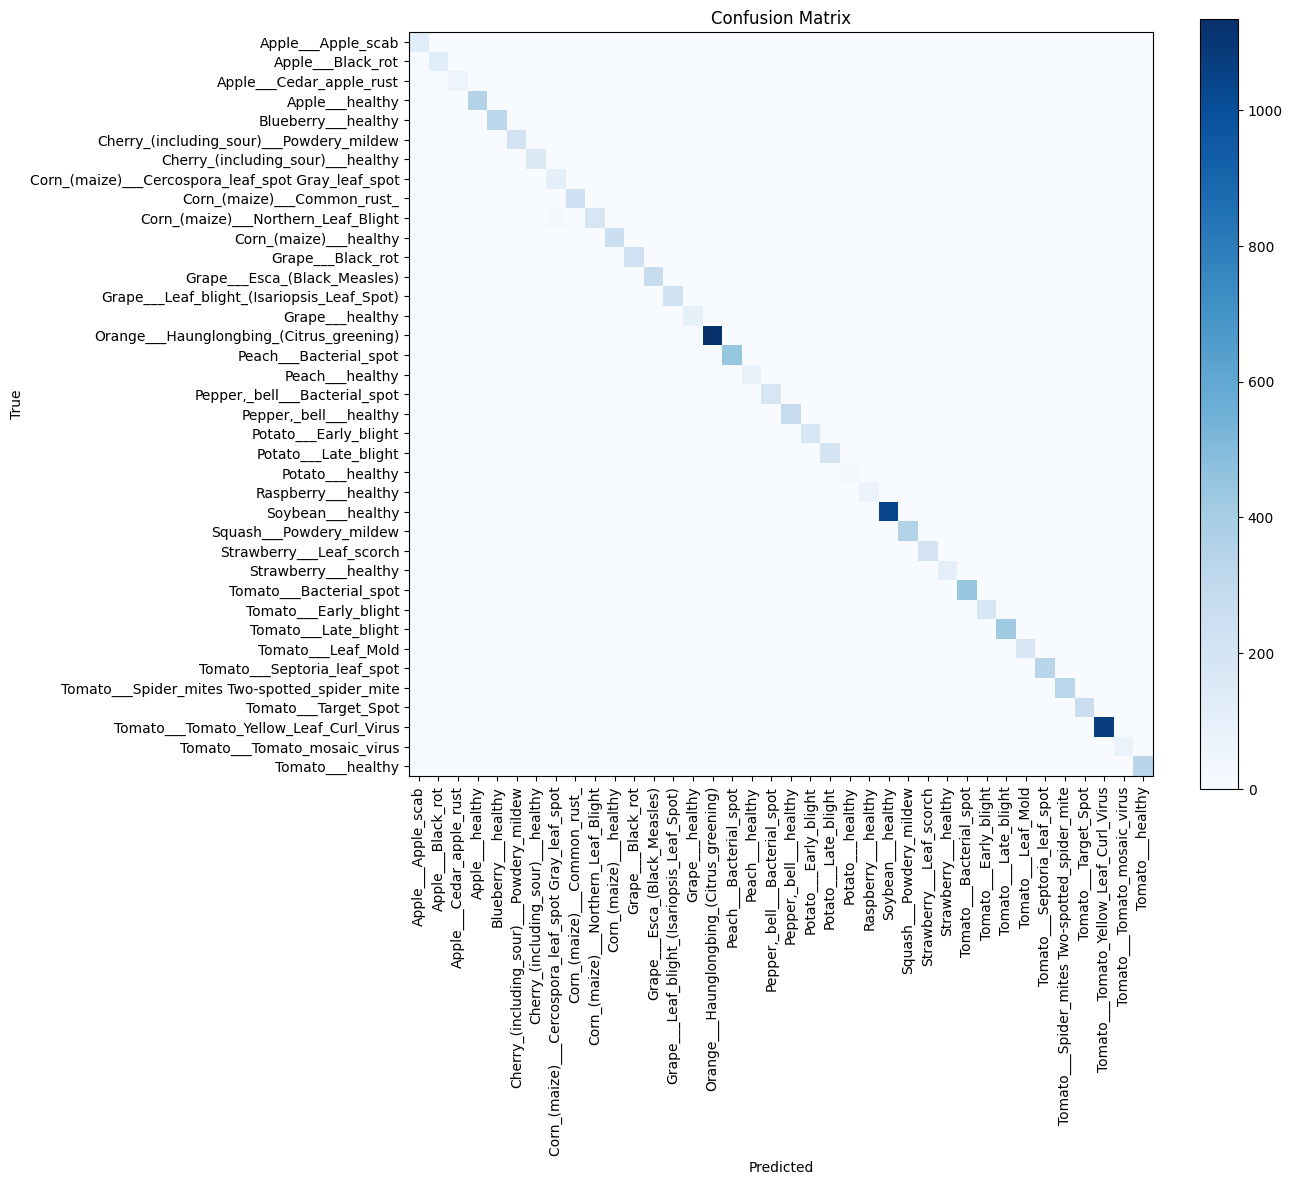


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9917    1.0000    0.9959       120
                                 Apple___Black_rot     1.0000    1.0000    1.0000       124
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        56
                                   Apple___healthy     0.9943    0.9971    0.9957       348
                               Blueberry___healthy     1.0000    1.0000    1.0000       318
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9904    0.9952       208
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8374    0.9450    0.8879       109
                       Corn_(maize)___Common_rust_     0.9958    1.0000    0.9979       238
               Corn_(maize)___Northern_Leaf_Blight    

In [15]:
# ==============================
# Imports
# ==============================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil

# ==============================
# 1. ECA Layer with get_config
# ==============================
class ECALayer(layers.Layer):
    def __init__(self, gamma=2, b=1, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.gamma = gamma
        self.b = b

    def build(self, input_shape):
        channels = input_shape[-1]
        t = int(abs((tf.math.log(tf.cast(channels, tf.float32)) / tf.math.log(2.0)) + self.b) / self.gamma)
        k = t if t % 2 else t + 1
        self.avg_pool = layers.GlobalAveragePooling2D(keepdims=True)
        self.conv = layers.Conv1D(1, kernel_size=k, padding="same", use_bias=False)
        self.sigmoid = layers.Activation("sigmoid")

    def call(self, x):
        y = self.avg_pool(x)
        y = tf.squeeze(y, axis=[1, 2])
        y = tf.expand_dims(y, axis=-1)
        y = self.conv(y)
        y = self.sigmoid(y)
        y = tf.reshape(y, [-1, 1, 1, x.shape[-1]])
        return x * y

    def get_config(self):
        config = super(ECALayer, self).get_config()
        config.update({
            "gamma": self.gamma,
            "b": self.b
        })
        return config

# ==============================
# 2. Dataset Loading
# ==============================
IMG_SIZE = (224, 224)
BATCH_SIZE = 24
data_dir = "/content/drive/MyDrive/plant_disease_project/PlantVillage"

# Move hidden folders temporarily
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if folder.startswith(".") and os.path.isdir(folder_path):
        shutil.move(folder_path, folder_path + "_backup")

# Training & validation datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==============================
# 3. Build Model: MobileNetV2 + ECA + Extra Layers
# ==============================
def build_mobilenetv2_eca(input_shape=(224, 224, 3), num_classes=38):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = True  # unfreeze backbone for fine-tuning

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=True)

    # Add ECA
    x = ECALayer()(x)

    # Extra Conv Layers
    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Extra Dense Layers
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs)
    return model

model = build_mobilenetv2_eca(input_shape=(224, 224, 3), num_classes=num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==============================
# 4. Train Model
# ==============================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50  # adjust as needed
)

# ==============================
# 5. Confusion Matrix + Classification Report
# ==============================
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report with decimals
all_labels = list(range(num_classes))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0, digits=4))

# ==============================
# 6. Save Model
# ==============================
model.save("mobilenetv2_eca_custom.h5")


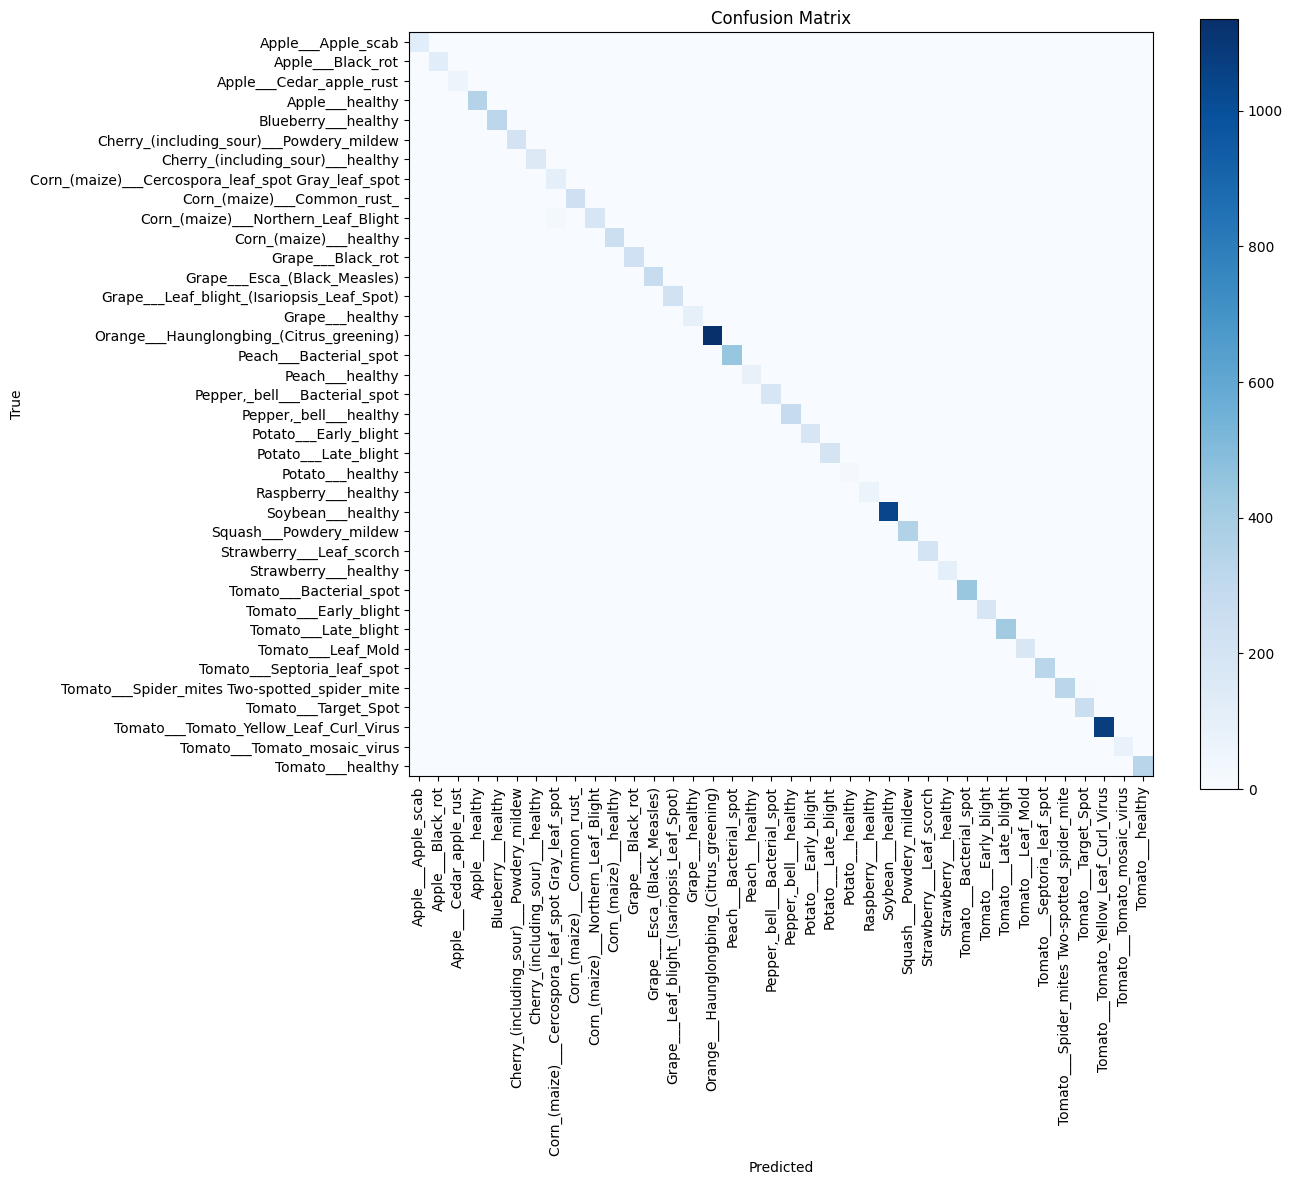


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9756    1.0000    0.9877       120
                                 Apple___Black_rot     1.0000    0.9839    0.9919       124
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        56
                                   Apple___healthy     0.9971    1.0000    0.9986       348
                               Blueberry___healthy     0.9969    1.0000    0.9984       318
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9904    0.9952       208
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8480    0.9725    0.9060       109
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       238
               Corn_(maize)___Northern_Leaf_Blight    

In [17]:
# ==============================
# Confusion Matrix + Classification Report
# ==============================
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
all_labels = list(range(num_classes))
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    labels=all_labels,
    target_names=class_names,
    zero_division=0,
    digits=4  # prints decimal values up to 4 digits
))


In [19]:
! pip install seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 1.4 MB/s eta 0:00:00a 0:00:01


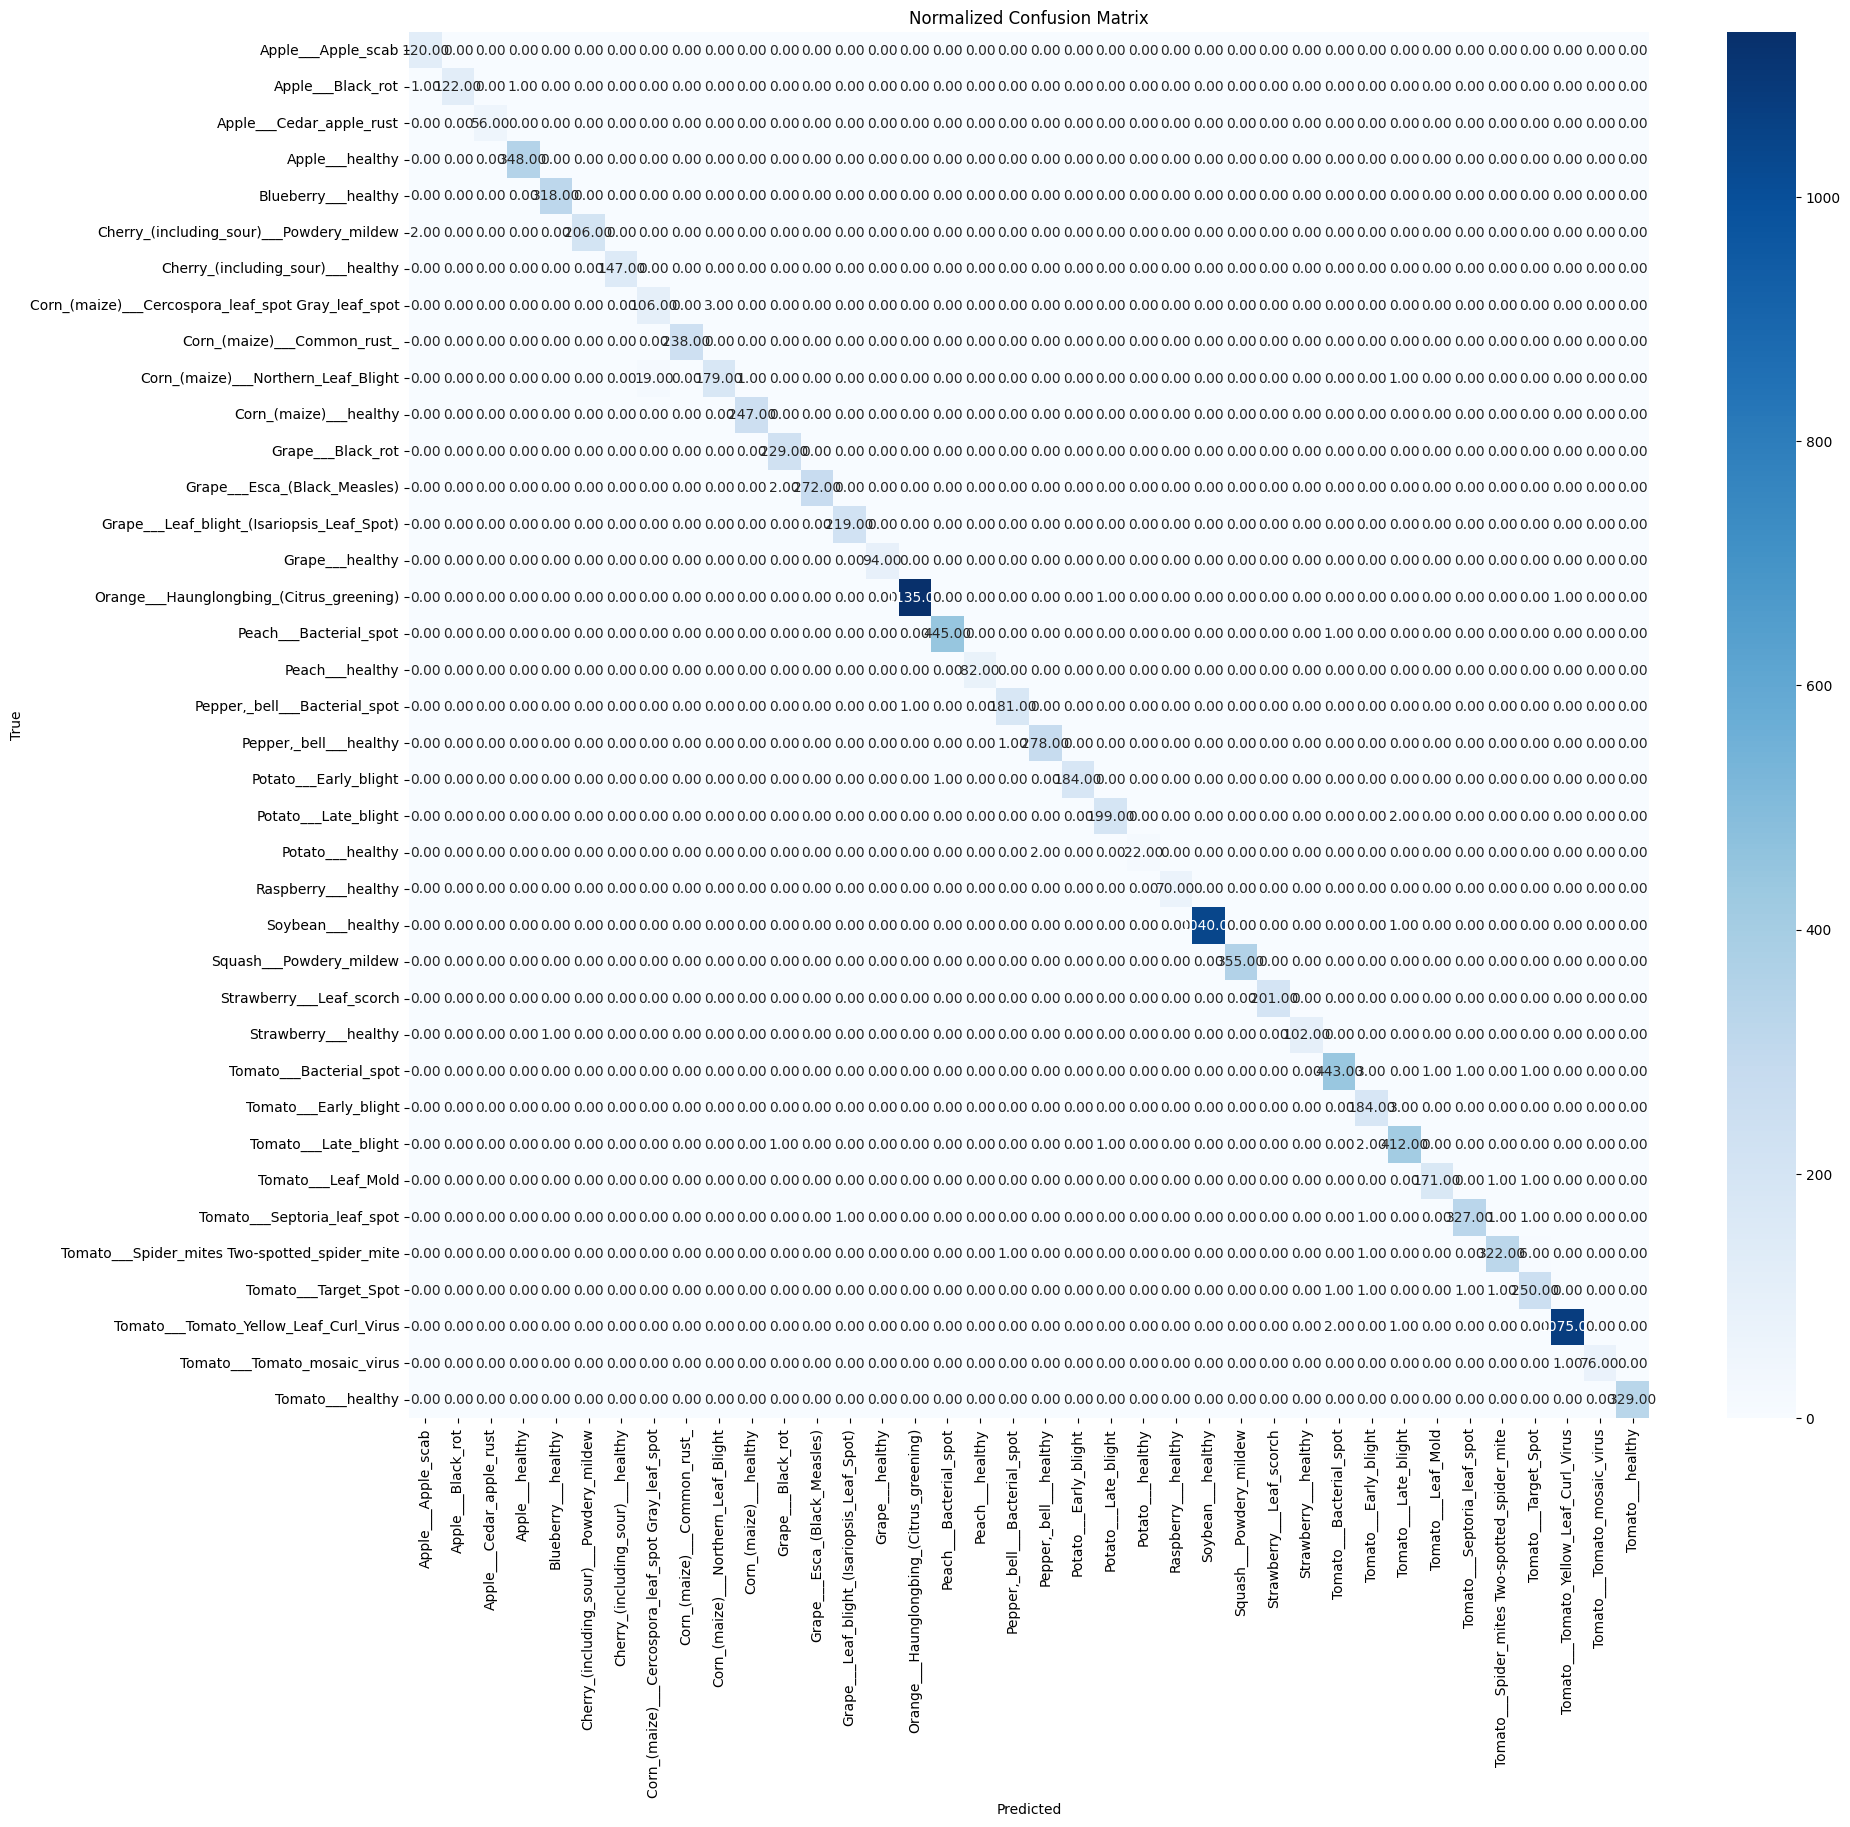

In [20]:
import seaborn as sns

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()
